In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

data = {
    'suhu_celsius': [20, 22, 24, 26, 28, 30, 32, 34, 36, 38],
    'penjualan':   [1.2, 1.5, 1.8, 2.2, 2.8, 3.4, 4.0, 4.7, 5.5, 6.0]
}

df = pd.DataFrame(data)
print(df)

   suhu_celsius  penjualan
0            20        1.2
1            22        1.5
2            24        1.8
3            26        2.2
4            28        2.8
5            30        3.4
6            32        4.0
7            34        4.7
8            36        5.5
9            38        6.0


Pada praktikum ini, saya membuat data sendiri yang menggambarkan hubungan antara suhu udara (°C) dan penjualan es krim (ratus ribu rupiah). Data terdiri dari 10 sampel dengan rentang suhu 20°C hingga 38°C. Tema ini dipilih karena mudah dipahami secara logis semakin tinggi suhu udara, semakin banyak es krim yang terjual.

In [17]:
x = df[['suhu_celsius']]
y = df['penjualan']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2,random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Data dibagi menjadi 80% data training (8 data) dan 20% data testing (2 data) menggunakan train_test_split. Model yang digunakan adalah Regresi Linear Sederhana dari library sklearn, dengan persamaan:

y = a + bx
di mana y = penjualan es krim,
x = suhu udara,
a = intercept,
b = koefisien/slope

In [18]:
print("Intercept (a) : ", model.intercept_)
print("Koefisien (b) : ", model.coef_[0])

Intercept (a) :  -4.699999999999999
Koefisien (b) :  0.27456896551724136


Berdasarkan hasil training, model menghasilkan:

Intercept (a) = -4.70 → Nilai ini bersifat matematis. Ketika suhu = 0°C, model memperkirakan penjualan bernilai negatif, yang dalam konteks nyata tidak mungkin terjadi. Hal ini wajar karena data training hanya mencakup suhu 20–38°C, sehingga prediksi di luar rentang tersebut kurang relevan.
Koefisien (b) = 0.2746 → Setiap kenaikan 1°C suhu, penjualan es krim naik sekitar Rp 27.460

In [19]:
y_pred = model.predict(x_test)

print("Data Testing : ")
print(x_test)
print("Penjualan Asli : ", y_test.values)
print("Penjualan Prediksi : ", y_pred)

Data Testing : 
   suhu_celsius
8            36
1            22
Penjualan Asli :  [5.5 1.5]
Penjualan Prediksi :  [5.18448276 1.34051724]


Hasil dan prediksi dari lean model dan data latih

In [20]:
print("MAE : ", metrics.mean_absolute_error(y_test, y_pred))
print("MSE : ", metrics.mean_squared_error(y_test, y_pred))
print("RMSE : ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE :  0.23750000000000027
MSE :  0.062492939952437765
RMSE :  0.24998587950609882


Metrik dan Interpretasi:
*   MAE  : Rata-rata selisih antara nilai prediksi dan nilai aktual
*   MSE  : Rata-rata kuadrat error lebih sensitif terhadap error besar
*   RMSE :Akar dari MSE, satuannya sama dengan data asli (ratus ribu).

Semakin kecil nilai MAE, MSE, dan RMSE, semakin akurat model dalam memprediksi penjualan.

In [21]:
prediksi = model.predict([[50]])

print("Prediksi Penjualan untuk suhu 40°C : ", prediksi[0])

Prediksi Penjualan untuk suhu 40°C :  9.028448275862068


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Dari model yang di latih dan di uji data prediksi menunjukkan
Jika suhu = 40°C, prediksi penjualan ≈ Rp 628.000 (≈ 6.28 ratus ribu), yang masuk akal mengikuti tren data.

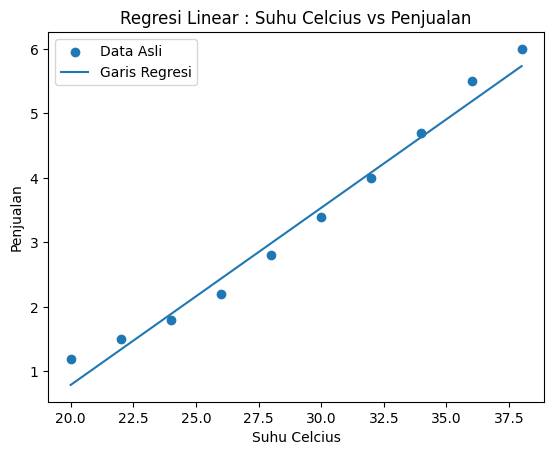

In [22]:
plt.scatter(x, y, label = "Data Asli")
plt.plot(x, model.predict(x), label = "Garis Regresi")
plt.xlabel("Suhu Celcius")
plt.ylabel("Penjualan")
plt.title("Regresi Linear : Suhu Celcius vs Penjualan")
plt.legend()
plt.show()